In [1]:
# =========================================================
# TASK 12 — BINARY CLASSIFICATION
# CELL 1 — SETUP
# =========================================================

import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

warnings.filterwarnings("ignore")

# Project root
PROJECT_ROOT = Path.cwd().parent

# Make project root importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=======================================================")
print("       TASK 12 — BINARY CLASSIFICATION")
print("=======================================================")
print(f"Project Root : {PROJECT_ROOT}")
print(f"Random Seed  : {RANDOM_STATE}")
print("Setup completed successfully.")

       TASK 12 — BINARY CLASSIFICATION
Project Root : /home/akash/Projects/Altrodav
Random Seed  : 42
Setup completed successfully.


In [2]:
# =========================================================
# TASK 12 — CELL 2
# LOAD DATA + CREATE BINARY TARGET
# =========================================================

from src.data import load_data

# Load the existing Iris dataset
df = load_data()

print("Original dataset shape:", df.shape)

print("\nOriginal target distribution:")
print(df["target"].value_counts().sort_index())

# Convert multiclass target into binary target
# Class 0 -> 0 (Negative)
# Classes 1 and 2 -> 1 (Positive)

df["binary_target"] = (
    df["target"] != 0
).astype(int)

# Remove original multiclass target
df = df.drop(columns=["target"])

print("\nBinary target distribution:")
print(df["binary_target"].value_counts().sort_index())

print("\nFinal dataset shape:", df.shape)

print("\nFinal columns:")
print(df.columns.tolist())

Original dataset shape: (150, 5)

Original target distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64

Binary target distribution:
binary_target
0     50
1    100
Name: count, dtype: int64

Final dataset shape: (150, 5)

Final columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'binary_target']


In [3]:
# =========================================================
# TASK 12 — CELL 3
# STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

# Separate features and binary target
X = df.drop(columns=["binary_target"])
y = df["binary_target"]

# First split:
# 70% training
# 30% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split:
# 15% validation
# 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("========== DATA SPLIT ==========")

print("Training set   :", X_train.shape)
print("Validation set :", X_val.shape)
print("Test set       :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation target distribution:")
print(y_val.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

========== DATA SPLIT ==========
Training set   : (105, 4)
Validation set : (22, 4)
Test set       : (23, 4)

Training target distribution:
binary_target
0    35
1    70
Name: count, dtype: int64

Validation target distribution:
binary_target
0     7
1    15
Name: count, dtype: int64

Test target distribution:
binary_target
0     8
1    15
Name: count, dtype: int64


In [4]:
# =========================================================
# TASK 12 — CELL 4
# FEATURE PREPROCESSING
# =========================================================

from src.features import (
    build_preprocessor,
    fit_preprocessor,
    transform_data
)

# All columns are numerical features
numerical_features = X_train.columns.tolist()

# Build preprocessing pipeline
preprocessor = build_preprocessor(
    numerical_features
)

# Fit ONLY on training data
preprocessor = fit_preprocessor(
    preprocessor,
    X_train
)

# Transform all datasets using the fitted preprocessor
X_train_processed = transform_data(
    preprocessor,
    X_train
)

X_val_processed = transform_data(
    preprocessor,
    X_val
)

X_test_processed = transform_data(
    preprocessor,
    X_test
)

print("========== PREPROCESSING ==========")
print("Numerical features:")
print(numerical_features)

print("\nProcessed training shape   :", X_train_processed.shape)
print("Processed validation shape :", X_val_processed.shape)
print("Processed test shape       :", X_test_processed.shape)

print("\nPreprocessor fitted only on training data.")

========== PREPROCESSING ==========
Numerical features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Processed training shape   : (105, 4)
Processed validation shape : (22, 4)
Processed test shape       : (23, 4)

Preprocessor fitted only on training data.


In [5]:
# =========================================================
# TASK 12 — CELL 5
# BASELINE BINARY CLASSIFIER
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Build baseline classifier
baseline_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=500
)

# Train on training data only
baseline_model.fit(
    X_train_processed,
    y_train
)

# Validation predictions
baseline_val_predictions = baseline_model.predict(
    X_val_processed
)

# Validation probabilities
baseline_val_probabilities = baseline_model.predict_proba(
    X_val_processed
)[:, 1]

# Calculate baseline metrics
baseline_accuracy = accuracy_score(
    y_val,
    baseline_val_predictions
)

baseline_precision = precision_score(
    y_val,
    baseline_val_predictions
)

baseline_recall = recall_score(
    y_val,
    baseline_val_predictions
)

baseline_f1 = f1_score(
    y_val,
    baseline_val_predictions
)

baseline_cm = confusion_matrix(
    y_val,
    baseline_val_predictions
)

print("========== BASELINE MODEL ==========")

print("Model              : Logistic Regression")
print(f"Validation Accuracy: {baseline_accuracy:.4f}")
print(f"Validation Precision: {baseline_precision:.4f}")
print(f"Validation Recall   : {baseline_recall:.4f}")
print(f"Validation F1       : {baseline_f1:.4f}")

print("\nConfusion Matrix:")
print(baseline_cm)

========== BASELINE MODEL ==========
Model              : Logistic Regression
Validation Accuracy: 1.0000
Validation Precision: 1.0000
Validation Recall   : 1.0000
Validation F1       : 1.0000

Confusion Matrix:
[[ 7  0]
 [ 0 15]]


In [6]:
# =========================================================
# TASK 12 — CELL 6
# TUNE THE BINARY CLASSIFIER
# =========================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Hyperparameter search space
param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Base classifier
tuning_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

# Stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Grid search
grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(
    X_train_processed,
    y_train
)

tuned_model = grid_search.best_estimator_

print("========== TUNED CLASSIFIER ==========")

print("Best Parameters:")
print(grid_search.best_params_)

print(
    f"\nBest CV F1: "
    f"{grid_search.best_score_:.4f}"
)

# Validation evaluation
tuned_val_predictions = tuned_model.predict(
    X_val_processed
)

tuned_val_probabilities = tuned_model.predict_proba(
    X_val_processed
)[:, 1]

tuned_val_accuracy = accuracy_score(
    y_val,
    tuned_val_predictions
)

tuned_val_precision = precision_score(
    y_val,
    tuned_val_predictions
)

tuned_val_recall = recall_score(
    y_val,
    tuned_val_predictions
)

tuned_val_f1 = f1_score(
    y_val,
    tuned_val_predictions
)

print("\nValidation Performance:")
print(f"Accuracy : {tuned_val_accuracy:.4f}")
print(f"Precision: {tuned_val_precision:.4f}")
print(f"Recall   : {tuned_val_recall:.4f}")
print(f"F1       : {tuned_val_f1:.4f}")

========== TUNED CLASSIFIER ==========
Best Parameters:
{'C': 0.1}

Best CV F1: 1.0000

Validation Performance:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000


In [7]:
# =========================================================
# TASK 12 — CELL 7
# PROBABILITY CALIBRATION
# =========================================================

from sklearn.calibration import CalibratedClassifierCV

# Calibrate the tuned classifier
calibrated_model = CalibratedClassifierCV(
    estimator=tuned_model,
    method="sigmoid",
    cv=5
)

# Fit calibration using training data only
calibrated_model.fit(
    X_train_processed,
    y_train
)

# Get calibrated probabilities on validation data
calibrated_val_probabilities = calibrated_model.predict_proba(
    X_val_processed
)[:, 1]

# Default 0.50 decision threshold
calibrated_val_predictions = (
    calibrated_val_probabilities >= 0.50
).astype(int)

calibrated_val_accuracy = accuracy_score(
    y_val,
    calibrated_val_predictions
)

calibrated_val_precision = precision_score(
    y_val,
    calibrated_val_predictions
)

calibrated_val_recall = recall_score(
    y_val,
    calibrated_val_predictions
)

calibrated_val_f1 = f1_score(
    y_val,
    calibrated_val_predictions
)

print("========== CALIBRATED CLASSIFIER ==========")

print("Calibration method : Sigmoid")
print("Cross-validation   : 5-fold")

print("\nValidation Performance at threshold 0.50:")
print(
    f"Accuracy  : {calibrated_val_accuracy:.4f}"
)
print(
    f"Precision : {calibrated_val_precision:.4f}"
)
print(
    f"Recall    : {calibrated_val_recall:.4f}"
)
print(
    f"F1        : {calibrated_val_f1:.4f}"
)

print("\nSample calibrated probabilities:")
print(
    np.round(
        calibrated_val_probabilities[:10],
        4
    )
)

========== CALIBRATED CLASSIFIER ==========
Calibration method : Sigmoid
Cross-validation   : 5-fold

Validation Performance at threshold 0.50:
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1        : 1.0000

Sample calibrated probabilities:
[0.9812 0.9745 0.9454 0.9784 0.8882 0.7392 0.1723 0.1035 0.139  0.9723]


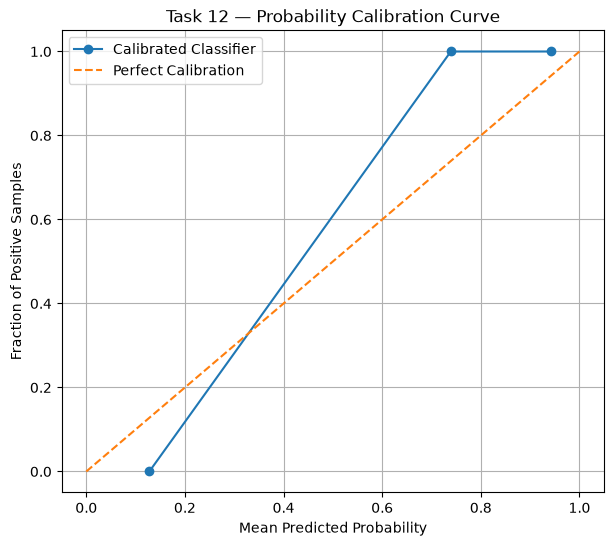

========== CALIBRATION RESULTS ==========
Brier Score: 0.0116

Calibration points:
   Mean Predicted Probability  Actual Positive Fraction
0                    0.127872                       0.0
1                    0.739154                       1.0
2                    0.943120                       1.0


In [8]:
# =========================================================
# TASK 12 — CELL 8
# CALIBRATION CURVE
# =========================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Calculate calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val,
    calibrated_val_probabilities,
    n_bins=5,
    strategy="uniform"
)

# Brier score
brier_score = brier_score_loss(
    y_val,
    calibrated_val_probabilities
)

# Plot calibration curve
plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="Calibrated Classifier"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positive Samples")
plt.title("Task 12 — Probability Calibration Curve")

plt.legend()
plt.grid(True)
plt.show()

print("========== CALIBRATION RESULTS ==========")
print(f"Brier Score: {brier_score:.4f}")

print("\nCalibration points:")

calibration_results = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Actual Positive Fraction": fraction_of_positives
})

print(calibration_results)

In [9]:
# =========================================================
# TASK 12 — CELL 9
# THRESHOLD / COST ANALYSIS
# =========================================================

from sklearn.metrics import confusion_matrix

# Define business-style costs
FALSE_POSITIVE_COST = 1
FALSE_NEGATIVE_COST = 3

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        calibrated_val_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions,
        labels=[0, 1]
    ).ravel()

    total_cost = (
        FALSE_POSITIVE_COST * fp
        + FALSE_NEGATIVE_COST * fn
    )

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Cost": total_cost,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results = pd.DataFrame(
    threshold_results
)

print("========== THRESHOLD / COST ANALYSIS ==========")

print(
    f"False Positive Cost : {FALSE_POSITIVE_COST}"
)

print(
    f"False Negative Cost : {FALSE_NEGATIVE_COST}"
)

print("\nThreshold results:")
print(
    threshold_results.round(4).to_string(index=False)
)

# Select threshold with minimum total cost
best_threshold_row = threshold_results.loc[
    threshold_results["Cost"].idxmin()
]

selected_threshold = float(
    best_threshold_row["Threshold"]
)

print("\n========== SELECTED OPERATING THRESHOLD ==========")
print(
    f"Selected Threshold : {selected_threshold:.2f}"
)
print(
    f"Minimum Cost       : "
    f"{best_threshold_row['Cost']:.0f}"
)

========== THRESHOLD / COST ANALYSIS ==========
False Positive Cost : 1
False Negative Cost : 3

Threshold results:
 Threshold  TP  TN  FP  FN  Cost  Precision  Recall     F1
      0.10  15   1   6   0     6     0.7143  1.0000 0.8333
      0.15  15   6   1   0     1     0.9375  1.0000 0.9677
      0.20  15   7   0   0     0     1.0000  1.0000 1.0000
      0.25  15   7   0   0     0     1.0000  1.0000 1.0000
      0.30  15   7   0   0     0     1.0000  1.0000 1.0000
      0.35  15   7   0   0     0     1.0000  1.0000 1.0000
      0.40  15   7   0   0     0     1.0000  1.0000 1.0000
      0.45  15   7   0   0     0     1.0000  1.0000 1.0000
      0.50  15   7   0   0     0     1.0000  1.0000 1.0000
      0.55  15   7   0   0     0     1.0000  1.0000 1.0000
      0.60  15   7   0   0     0     1.0000  1.0000 1.0000
      0.65  15   7   0   0     0     1.0000  1.0000 1.0000
      0.70  15   7   0   0     0     1.0000  1.0000 1.0000
      0.75  14   7   0   1     3     1.0000  0.9333 0.9655

In [10]:
# =========================================================
# TASK 12 — CELL 10
# FINAL UNSEEN TEST EVALUATION
# =========================================================

# Get calibrated probabilities on the untouched test set
calibrated_test_probabilities = calibrated_model.predict_proba(
    X_test_processed
)[:, 1]

# Apply the selected operating threshold
calibrated_test_predictions = (
    calibrated_test_probabilities >= selected_threshold
).astype(int)

# Calculate test metrics
test_accuracy = accuracy_score(
    y_test,
    calibrated_test_predictions
)

test_precision = precision_score(
    y_test,
    calibrated_test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    calibrated_test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    calibrated_test_predictions,
    zero_division=0
)

test_cm = confusion_matrix(
    y_test,
    calibrated_test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = test_cm.ravel()

print("========== FINAL TEST EVALUATION ==========")

print(f"Operating Threshold : {selected_threshold:.2f}")

print(f"\nTest Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1        : {test_f1:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

print("\nError Analysis:")
print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")

========== FINAL TEST EVALUATION ==========
Operating Threshold : 0.20

Test Accuracy  : 0.9565
Test Precision : 0.9375
Test Recall    : 1.0000
Test F1        : 0.9677

Confusion Matrix:
[[ 7  1]
 [ 0 15]]

Error Analysis:
True Negatives  : 7
False Positives : 1
False Negatives : 0
True Positives  : 15


In [11]:
# =========================================================
# TASK 12 — CELL 11
# CROSS-FOLD + SEGMENT STABILITY
# =========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_results = []

for fold_number, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Build a fresh preprocessor for each fold
    fold_preprocessor = build_preprocessor(
        numerical_features
    )

    fold_preprocessor.fit(X_fold_train)

    X_fold_train_processed = fold_preprocessor.transform(
        X_fold_train
    )

    X_fold_val_processed = fold_preprocessor.transform(
        X_fold_val
    )

    # Fresh classifier
    fold_model = clone(tuned_model)

    fold_model.fit(
        X_fold_train_processed,
        y_fold_train
    )

    # Calibrate within the fold
    fold_calibrated_model = CalibratedClassifierCV(
        estimator=fold_model,
        method="sigmoid",
        cv=3
    )

    fold_calibrated_model.fit(
        X_fold_train_processed,
        y_fold_train
    )

    # Fold probabilities
    fold_probabilities = fold_calibrated_model.predict_proba(
        X_fold_val_processed
    )[:, 1]

    fold_predictions = (
        fold_probabilities >= selected_threshold
    ).astype(int)

    fold_results.append({
        "Fold": fold_number,
        "Accuracy": accuracy_score(
            y_fold_val,
            fold_predictions
        ),
        "Precision": precision_score(
            y_fold_val,
            fold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_fold_val,
            fold_predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_fold_val,
            fold_predictions,
            zero_division=0
        )
    })

fold_results = pd.DataFrame(fold_results)

print("========== CROSS-FOLD STABILITY ==========")
print(
    fold_results.round(4).to_string(index=False)
)

print("\nMean metrics:")
print(
    fold_results[
        ["Accuracy", "Precision", "Recall", "F1"]
    ].mean().round(4)
)

print("\nMetric standard deviation:")
print(
    fold_results[
        ["Accuracy", "Precision", "Recall", "F1"]
    ].std().round(4)
)

# =========================================================
# SEGMENT / CLASS PERFORMANCE
# =========================================================

segment_results = []

for segment in [0, 1]:

    mask = y_test == segment

    segment_predictions = (
        calibrated_test_predictions[mask]
    )

    segment_actual = y_test[mask]

    segment_results.append({
        "Segment": segment,
        "Samples": int(mask.sum()),
        "Correct": int(
            (segment_predictions == segment_actual).sum()
        ),
        "Accuracy": accuracy_score(
            segment_actual,
            segment_predictions
        )
    })

segment_results = pd.DataFrame(
    segment_results
)

print("\n========== SEGMENT / CLASS STABILITY ==========")
print(
    segment_results.round(4).to_string(index=False)
)

========== CROSS-FOLD STABILITY ==========
 Fold  Accuracy  Precision  Recall     F1
    1    1.0000     1.0000     1.0 1.0000
    2    1.0000     1.0000     1.0 1.0000
    3    1.0000     1.0000     1.0 1.0000
    4    0.9524     0.9333     1.0 0.9655
    5    1.0000     1.0000     1.0 1.0000

Mean metrics:
Accuracy     0.9905
Precision    0.9867
Recall       1.0000
F1           0.9931
dtype: float64

Metric standard deviation:
Accuracy     0.0213
Precision    0.0298
Recall       0.0000
F1           0.0154
dtype: float64

========== SEGMENT / CLASS STABILITY ==========
 Segment  Samples  Correct  Accuracy
       0        8        7     0.875
       1       15       15     1.000


In [12]:
# =========================================================
# TASK 12 — CELL 12
# OPERATING-POINT SUMMARY
# =========================================================

test_total = len(y_test)

false_positive_rate = fp / test_total
false_negative_rate = fn / test_total

operating_point = {
    "Threshold": selected_threshold,
    "False Positive Cost": FALSE_POSITIVE_COST,
    "False Negative Cost": FALSE_NEGATIVE_COST,
    "Test Accuracy": test_accuracy,
    "Test Precision": test_precision,
    "Test Recall": test_recall,
    "Test F1": test_f1,
    "False Positive Rate": false_positive_rate,
    "False Negative Rate": false_negative_rate,
    "False Positives": fp,
    "False Negatives": fn
}

operating_point_df = pd.DataFrame(
    [operating_point]
)

print("=======================================================")
print("        TASK 12 — OPERATING POINT SUMMARY")
print("=======================================================")

print(
    operating_point_df.round(4).to_string(index=False)
)

print("\nDecision Policy:")
print(
    f"Predict class 1 when probability >= "
    f"{selected_threshold:.2f}"
)

print("\nExpected Test Error Rates:")
print(
    f"False Positive Rate : {false_positive_rate:.4f}"
)

print(
    f"False Negative Rate : {false_negative_rate:.4f}"
)

        TASK 12 — OPERATING POINT SUMMARY
 Threshold  False Positive Cost  False Negative Cost  Test Accuracy  Test Precision  Test Recall  Test F1  False Positive Rate  False Negative Rate  False Positives  False Negatives
       0.2                    1                    3         0.9565          0.9375          1.0   0.9677               0.0435                  0.0                1                0

Decision Policy:
Predict class 1 when probability >= 0.20

Expected Test Error Rates:
False Positive Rate : 0.0435
False Negative Rate : 0.0000


In [13]:
# =========================================================
# TASK 12 — CELL 13
# PACKAGE MODEL FOR SERVING
# =========================================================

import joblib

# Ensure models directory exists
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Paths
preprocessor_path = (
    models_dir / "task12_preprocessor.pkl"
)

model_path = (
    models_dir / "task12_calibrated_model.pkl"
)

threshold_path = (
    models_dir / "task12_threshold.pkl"
)

# Save preprocessor
joblib.dump(
    preprocessor,
    preprocessor_path
)

# Save calibrated classifier
joblib.dump(
    calibrated_model,
    model_path
)

# Save operating threshold
joblib.dump(
    selected_threshold,
    threshold_path
)

print("========== MODEL PACKAGING ==========")

print("Preprocessor saved to:")
print(preprocessor_path)

print("\nCalibrated model saved to:")
print(model_path)

print("\nOperating threshold saved to:")
print(threshold_path)

print("\nPackaging completed successfully.")

========== MODEL PACKAGING ==========
Preprocessor saved to:
/home/akash/Projects/Altrodav/models/task12_preprocessor.pkl

Calibrated model saved to:
/home/akash/Projects/Altrodav/models/task12_calibrated_model.pkl

Operating threshold saved to:
/home/akash/Projects/Altrodav/models/task12_threshold.pkl

Packaging completed successfully.


In [14]:
# =========================================================
# TASK 12 — CELL 14
# SERVING-STYLE INFERENCE
# =========================================================

import joblib
import pandas as pd
import numpy as np

# Reload packaged artifacts
loaded_preprocessor = joblib.load(
    preprocessor_path
)

loaded_model = joblib.load(
    model_path
)

loaded_threshold = joblib.load(
    threshold_path
)

# Take one raw sample from the original test set
sample = X_test.iloc[[0]]

# Transform raw input using saved preprocessor
sample_processed = loaded_preprocessor.transform(
    sample
)

# Generate calibrated probability
sample_probability = loaded_model.predict_proba(
    sample_processed
)[:, 1][0]

# Apply saved operating threshold
sample_prediction = int(
    sample_probability >= loaded_threshold
)

print("========== SERVING-STYLE INFERENCE ==========")

print("\nRaw input:")
print(sample.to_string(index=False))

print(
    f"\nCalibrated probability: "
    f"{sample_probability:.4f}"
)

print(
    f"Decision threshold    : "
    f"{loaded_threshold:.2f}"
)

print(
    f"Final prediction      : "
    f"{sample_prediction}"
)

print("\nInference pipeline:")
print("Raw Input")
print("   ↓")
print("Saved Preprocessor")
print("   ↓")
print("Calibrated Model")
print("   ↓")
print("Probability")
print("   ↓")
print("Saved Threshold")
print("   ↓")
print("Final Decision")

print("\nServing-style inference completed successfully.")

========== SERVING-STYLE INFERENCE ==========

Raw input:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
               4.4               3.0                1.3               0.2

Calibrated probability: 0.1301
Decision threshold    : 0.20
Final prediction      : 0

Inference pipeline:
Raw Input
   ↓
Saved Preprocessor
   ↓
Calibrated Model
   ↓
Probability
   ↓
Saved Threshold
   ↓
Final Decision

Serving-style inference completed successfully.


In [15]:
# =========================================================
# TASK 12 — CELL 15
# FINAL VERIFICATION + RESULTS ARTIFACT
# =========================================================

from pathlib import Path
import pandas as pd

# Create artifact directory
artifact_dir = PROJECT_ROOT / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

# Final results
final_results = {
    "Task": "Task 12 — Binary Classification",
    "Dataset": "Iris",
    "Model": "Calibrated Logistic Regression",
    "Calibration Method": "Sigmoid",
    "Selected Threshold": selected_threshold,
    "False Positive Cost": FALSE_POSITIVE_COST,
    "False Negative Cost": FALSE_NEGATIVE_COST,
    "Validation Brier Score": brier_score,
    "Test Accuracy": test_accuracy,
    "Test Precision": test_precision,
    "Test Recall": test_recall,
    "Test F1": test_f1,
    "False Positive Rate": false_positive_rate,
    "False Negative Rate": false_negative_rate,
    "False Positives": fp,
    "False Negatives": fn,
    "Mean CV Accuracy": fold_results["Accuracy"].mean(),
    "Mean CV Precision": fold_results["Precision"].mean(),
    "Mean CV Recall": fold_results["Recall"].mean(),
    "Mean CV F1": fold_results["F1"].mean(),
    "CV Accuracy Std": fold_results["Accuracy"].std(),
    "CV F1 Std": fold_results["F1"].std(),
    "Status": "Completed"
}

final_results_df = pd.DataFrame(
    [final_results]
)

# Save artifact
artifact_path = (
    artifact_dir / "task12_binary_classification_results.csv"
)

final_results_df.to_csv(
    artifact_path,
    index=False
)

print("=======================================================")
print("        TASK 12 — FINAL VERIFICATION")
print("=======================================================")

print("\nModel:")
print("Calibrated Logistic Regression")

print(
    f"\nCalibration Brier Score : "
    f"{brier_score:.4f}"
)

print(
    f"Operating Threshold     : "
    f"{selected_threshold:.2f}"
)

print(
    f"Test Accuracy           : "
    f"{test_accuracy:.4f}"
)

print(
    f"Test Precision          : "
    f"{test_precision:.4f}"
)

print(
    f"Test Recall             : "
    f"{test_recall:.4f}"
)

print(
    f"Test F1                 : "
    f"{test_f1:.4f}"
)

print(
    f"False Positive Rate     : "
    f"{false_positive_rate:.4f}"
)

print(
    f"False Negative Rate     : "
    f"{false_negative_rate:.4f}"
)

print(
    f"\nMean CV Accuracy        : "
    f"{fold_results['Accuracy'].mean():.4f}"
)

print(
    f"Mean CV F1              : "
    f"{fold_results['F1'].mean():.4f}"
)

print("\nArtifacts:")
print("Preprocessor :", preprocessor_path)
print("Model        :", model_path)
print("Threshold    :", threshold_path)
print("Results      :", artifact_path)

print("\n=======================================================")
print("TASK 12 COMPLETED SUCCESSFULLY!")
print("=======================================================")

        TASK 12 — FINAL VERIFICATION

Model:
Calibrated Logistic Regression

Calibration Brier Score : 0.0116
Operating Threshold     : 0.20
Test Accuracy           : 0.9565
Test Precision          : 0.9375
Test Recall             : 1.0000
Test F1                 : 0.9677
False Positive Rate     : 0.0435
False Negative Rate     : 0.0000

Mean CV Accuracy        : 0.9905
Mean CV F1              : 0.9931

Artifacts:
Preprocessor : /home/akash/Projects/Altrodav/models/task12_preprocessor.pkl
Model        : /home/akash/Projects/Altrodav/models/task12_calibrated_model.pkl
Threshold    : /home/akash/Projects/Altrodav/models/task12_threshold.pkl
Results      : /home/akash/Projects/Altrodav/artifacts/task12_binary_classification_results.csv

TASK 12 COMPLETED SUCCESSFULLY!
